# ElasticNet Model for Cryptocurrency Price Prediction

This notebook focuses on training an ElasticNet regression model for cryptocurrency price prediction:

1. Load the prepared data
2. Train an ElasticNet regression model
3. Evaluate model performance
4. Save the model for later use

ElasticNet is a linear regression model with combined L1 and L2 regularization. It's particularly useful for handling datasets with potential multicollinearity (correlated features), which is common in financial time series data.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import explained_variance_score, median_absolute_error

# Set random seed for reproducibility
np.random.seed(42)

# Check if models directory exists
os.makedirs('../models', exist_ok=True)

In [2]:
# Load the train-test split data
with open('../models/train_test_split.pkl', 'rb') as f:
    data = pickle.load(f)
    
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
dates_train = data['dates_train']
dates_test = data['dates_test']

# Load feature list
with open('../models/features.pkl', 'rb') as f:
    features = pickle.load(f)

print(f"Loaded training data with {len(X_train)} samples and {X_train.shape[1]} features")
print(f"Loaded testing data with {len(X_test)} samples")
print(f"Features: {features}")

Loaded training data with 659668 samples and 13 features
Loaded testing data with 164918 samples
Features: ['open', 'high', 'low', 'close', 'volume', 'spread', 'return', 'ma_3', 'ma_7', 'ma_14', 'volatility_7', 'close_lag1', 'volume_lag1']


In [7]:
# Function to evaluate regression models
def evaluate_regression_model(y_true, y_pred):
    """
    Calculate common regression metrics for model evaluation.
    
    Parameters:
        y_true: True target values
        y_pred: Predicted target values
        
    Returns:
        Dictionary of evaluation metrics
    """
    # Ensure arrays have the same length
    if len(y_true) != len(y_pred):
        min_length = min(len(y_true), len(y_pred))
        y_true = y_true[:min_length]
        y_pred = y_pred[:min_length]
        print(f"Warning: Arrays had different lengths. Truncated to {min_length} elements.")
    
    # Calculate metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    explained_var = explained_variance_score(y_true, y_pred)
    median_ae = median_absolute_error(y_true, y_pred)
    
    # Calculate MAPE with handling for zeros
    epsilon = 1e-10
    y_true_safe = np.maximum(np.abs(y_true), epsilon)
    mape = np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100
    
    # Calculate directional accuracy (how often the direction of change is correct)
    # Convert to numpy arrays to ensure consistent indexing behavior
    y_true_np = np.array(y_true)
    y_pred_np = np.array(y_pred)
    
    # Calculate directions
    actual_direction = np.sign(y_true_np[1:] - y_true_np[:-1])
    pred_direction = np.sign(y_pred_np[1:] - y_pred_np[:-1])
    
    # Ensure lengths match for comparison (they should, but just to be safe)
    min_dir_length = min(len(actual_direction), len(pred_direction))
    directional_accuracy = np.mean(actual_direction[:min_dir_length] == pred_direction[:min_dir_length]) * 100
    
    return {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'MAPE (%)': mape,
        'Explained Variance': explained_var,
        'Median AE': median_ae,
        'Directional Accuracy (%)': directional_accuracy
    }

## Data Preprocessing for ElasticNet

Unlike tree-based models, ElasticNet is sensitive to feature scaling, so we'll need to standardize our features.

In [8]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features have been standardized for ElasticNet model training")

Features have been standardized for ElasticNet model training


## ElasticNet Model Training

We'll train an ElasticNet regression model with tuned hyperparameters for cryptocurrency price prediction.

In [9]:
# Set ElasticNet parameters
params = {
    'alpha': 0.5,        # Controls overall regularization strength
    'l1_ratio': 0.5,     # 0.5 means equal weight to L1 and L2 penalties
    'fit_intercept': True,
    'max_iter': 10000,   # Allow more iterations for convergence
    'tol': 0.0001,       # Tolerance for stopping criteria
    'random_state': 42
}

# Initialize and train ElasticNet model
print("Training ElasticNet model...")
elastic_model = ElasticNet(**params)
elastic_model.fit(X_train_scaled, y_train)

print("Training completed!")

Training ElasticNet model...
Training completed!
Training completed!


In [10]:
# Make predictions
train_preds = elastic_model.predict(X_train_scaled)
test_preds = elastic_model.predict(X_test_scaled)

# Evaluate model performance
train_metrics = evaluate_regression_model(y_train, train_preds)
test_metrics = evaluate_regression_model(y_test, test_preds)

# Print metrics
print("\nTraining set metrics:")
for metric, value in train_metrics.items():
    if metric in ['MAE', 'RMSE', 'Median AE']:
        print(f"  {metric}: ${value:.4f}")
    elif metric in ['MAPE (%)', 'Directional Accuracy (%)']:
        print(f"  {metric}: {value:.2f}%")
    else:
        print(f"  {metric}: {value:.4f}")

print("\nTest set metrics:")
for metric, value in test_metrics.items():
    if metric in ['MAE', 'RMSE', 'Median AE']:
        print(f"  {metric}: ${value:.4f}")
    elif metric in ['MAPE (%)', 'Directional Accuracy (%)']:
        print(f"  {metric}: {value:.2f}%")
    else:
        print(f"  {metric}: {value:.4f}")


Training set metrics:
  MAE: $797.1446
  RMSE: $14969.9198
  R²: 0.0002
  MAPE (%): 4563210326.64%
  Explained Variance: 0.0002
  Median AE: $393.6736
  Directional Accuracy (%): 46.96%

Test set metrics:
  MAE: $539.6070
  RMSE: $4294.9187
  R²: -0.0043
  MAPE (%): 707927820.64%
  Explained Variance: -0.0007
  Median AE: $393.7013
  Directional Accuracy (%): 47.36%


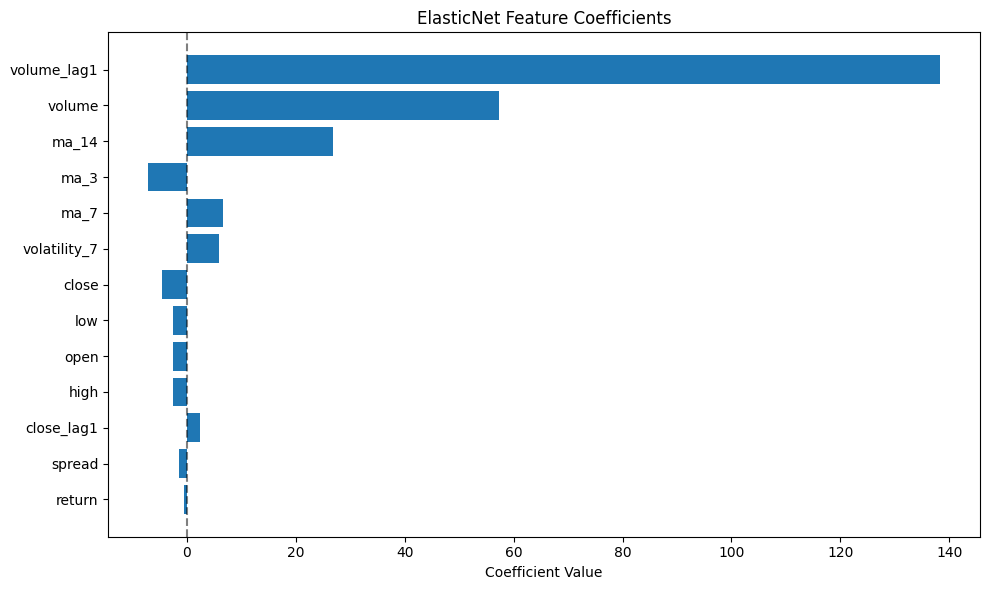

Number of features selected by ElasticNet: 13 out of 13
  open: -2.4754
  high: -2.4359
  low: -2.5203
  close: -4.4672
  volume: 57.3742
  spread: -1.5004
  return: -0.4176
  ma_3: -7.1183
  ma_7: 6.6521
  ma_14: 26.8112
  volatility_7: 5.9084
  close_lag1: 2.4116
  volume_lag1: 138.3518


In [11]:
# Visualize feature coefficients
plt.figure(figsize=(10, 6))
feature_coeffs = elastic_model.coef_
sorted_idx = np.argsort(np.abs(feature_coeffs))
plt.barh(np.array(features)[sorted_idx], feature_coeffs[sorted_idx])
plt.title('ElasticNet Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Print non-zero coefficients (features selected by the model)
non_zero_features = [(feature, coef) for feature, coef in zip(features, feature_coeffs) if coef != 0]
print(f"Number of features selected by ElasticNet: {len(non_zero_features)} out of {len(features)}")
for feature, coef in non_zero_features:
    print(f"  {feature}: {coef:.4f}")

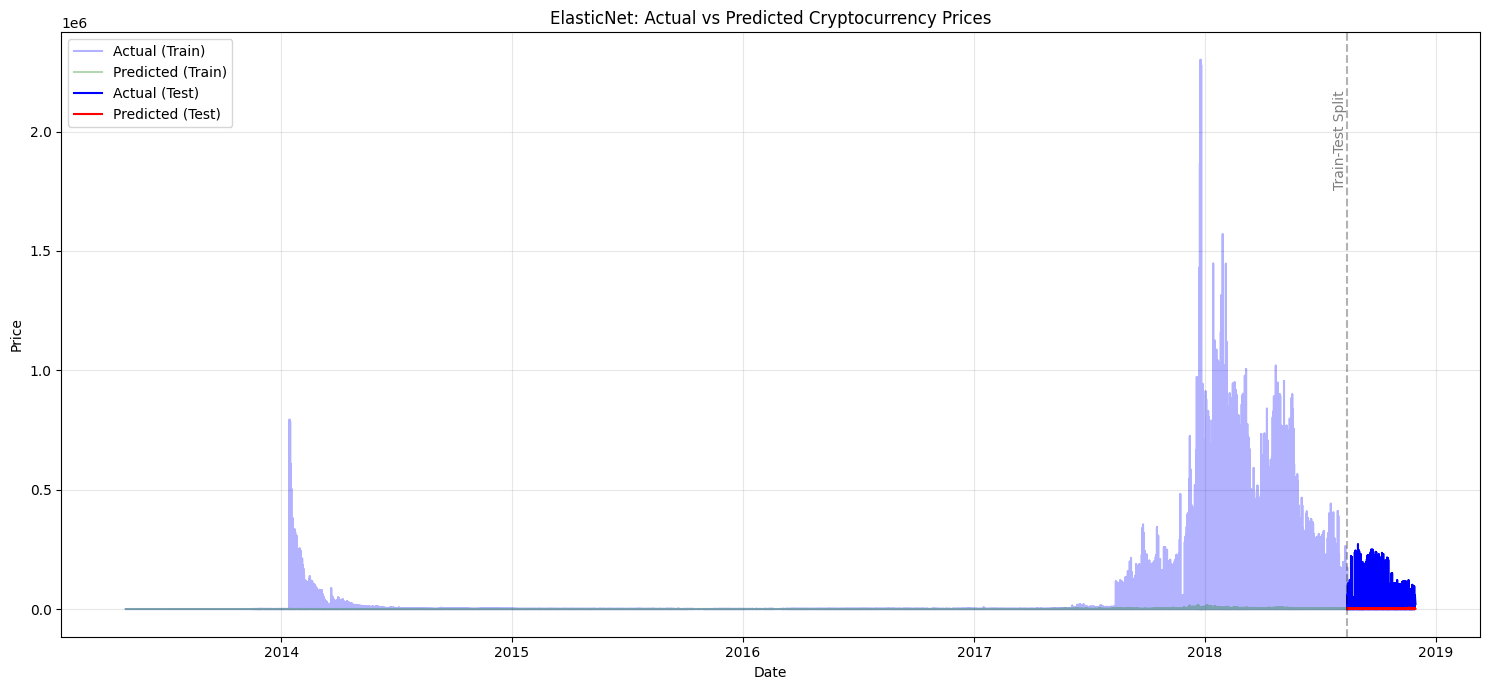

In [12]:
# Visualize actual vs predicted prices
plt.figure(figsize=(15, 7))

# Plot training data
plt.plot(dates_train, y_train, 'b-', label='Actual (Train)', alpha=0.3)
plt.plot(dates_train, train_preds, 'g-', label='Predicted (Train)', alpha=0.3)

# Plot test data
plt.plot(dates_test, y_test, 'b-', label='Actual (Test)')
plt.plot(dates_test, test_preds, 'r-', label='Predicted (Test)')

# Add vertical line to separate train and test sets
plt.axvline(x=dates_train.iloc[-1], color='k', linestyle='--', alpha=0.3)
plt.text(dates_train.iloc[-1], plt.ylim()[1]*0.9, 'Train-Test Split', 
         ha='right', va='top', rotation=90, alpha=0.5)

plt.title('ElasticNet: Actual vs Predicted Cryptocurrency Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Save Model and Metrics

Save the trained ElasticNet model, the scaler, and the performance metrics for later use in model comparison.

In [13]:
# Save the model and metadata
model_name = 'elasticnet'
model_filename = f'../models/{model_name}_model.pkl'
scaler_filename = f'../models/{model_name}_scaler.pkl'

# Save the model
with open(model_filename, 'wb') as f:
    pickle.dump(elastic_model, f)

# Save the scaler
with open(scaler_filename, 'wb') as f:
    pickle.dump(scaler, f)

# Save model metadata
model_metadata = {
    'name': 'ElasticNet',
    'features': features,
    'metrics': {
        'train': train_metrics,
        'test': test_metrics
    },
    'params': params,
    'feature_coefficients': {feature: coef for feature, coef in zip(features, feature_coeffs)},
    'date_trained': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'requires_scaling': True
}

metadata_filename = f'../models/{model_name}_metadata.pkl'
with open(metadata_filename, 'wb') as f:
    pickle.dump(model_metadata, f)

# Save predictions
predictions = {
    'train': {
        'dates': dates_train,
        'actual': y_train,
        'predicted': train_preds
    },
    'test': {
        'dates': dates_test,
        'actual': y_test,
        'predicted': test_preds
    }
}

predictions_filename = f'../models/{model_name}_predictions.pkl'
with open(predictions_filename, 'wb') as f:
    pickle.dump(predictions, f)

print(f"Model saved to: {model_filename}")
print(f"Scaler saved to: {scaler_filename}")
print(f"Metadata saved to: {metadata_filename}")
print(f"Predictions saved to: {predictions_filename}")

Model saved to: ../models/elasticnet_model.pkl
Scaler saved to: ../models/elasticnet_scaler.pkl
Metadata saved to: ../models/elasticnet_metadata.pkl
Predictions saved to: ../models/elasticnet_predictions.pkl
